In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# ==========================================
# 1. Definición de la función de ecualización local
# ==========================================
def ecualizacion_local_histograma(img, ksize=(15, 15)):
    """
    Realiza la ecualización local del histograma pixel a pixel.

    img: numpy array 2D (uint8)
    ksize: tupla (M, N) tamaño de la ventana
    """
    M, N = ksize
    pad_y = M // 2
    pad_x = N // 2

    # Agregar borde
    img_padded = cv2.copyMakeBorder(
        img,
        top=pad_y,
        bottom=pad_y,
        left=pad_x,
        right=pad_x,
        borderType=cv2.BORDER_REPLICATE
    )

    alto, ancho = img.shape
    img_salida = np.zeros((alto, ancho), dtype=np.uint8)
    total_pixeles = M * N

    # Recorrido pixel a pixel
    for i in range(alto):
        for j in range(ancho):

            # Extraer el vecindario local MxN
            vecindario = img_padded[i:i + M, j:j + N]

            # Histograma del vecindario
            histograma = cv2.calcHist(
                [vecindario],
                [0],
                None,
                [256],
                [0, 256]
            ).flatten()

            # Frecuencia acumulada (CDF)
            cdf = (histograma / total_pixeles).cumsum()

            # Valor del píxel central
            val_central = img[i, j]

            # Aplicar transformación de ecualización
            nuevo_val = np.round(255 * cdf[val_central])

            img_salida[i, j] = nuevo_val

    return img_salida

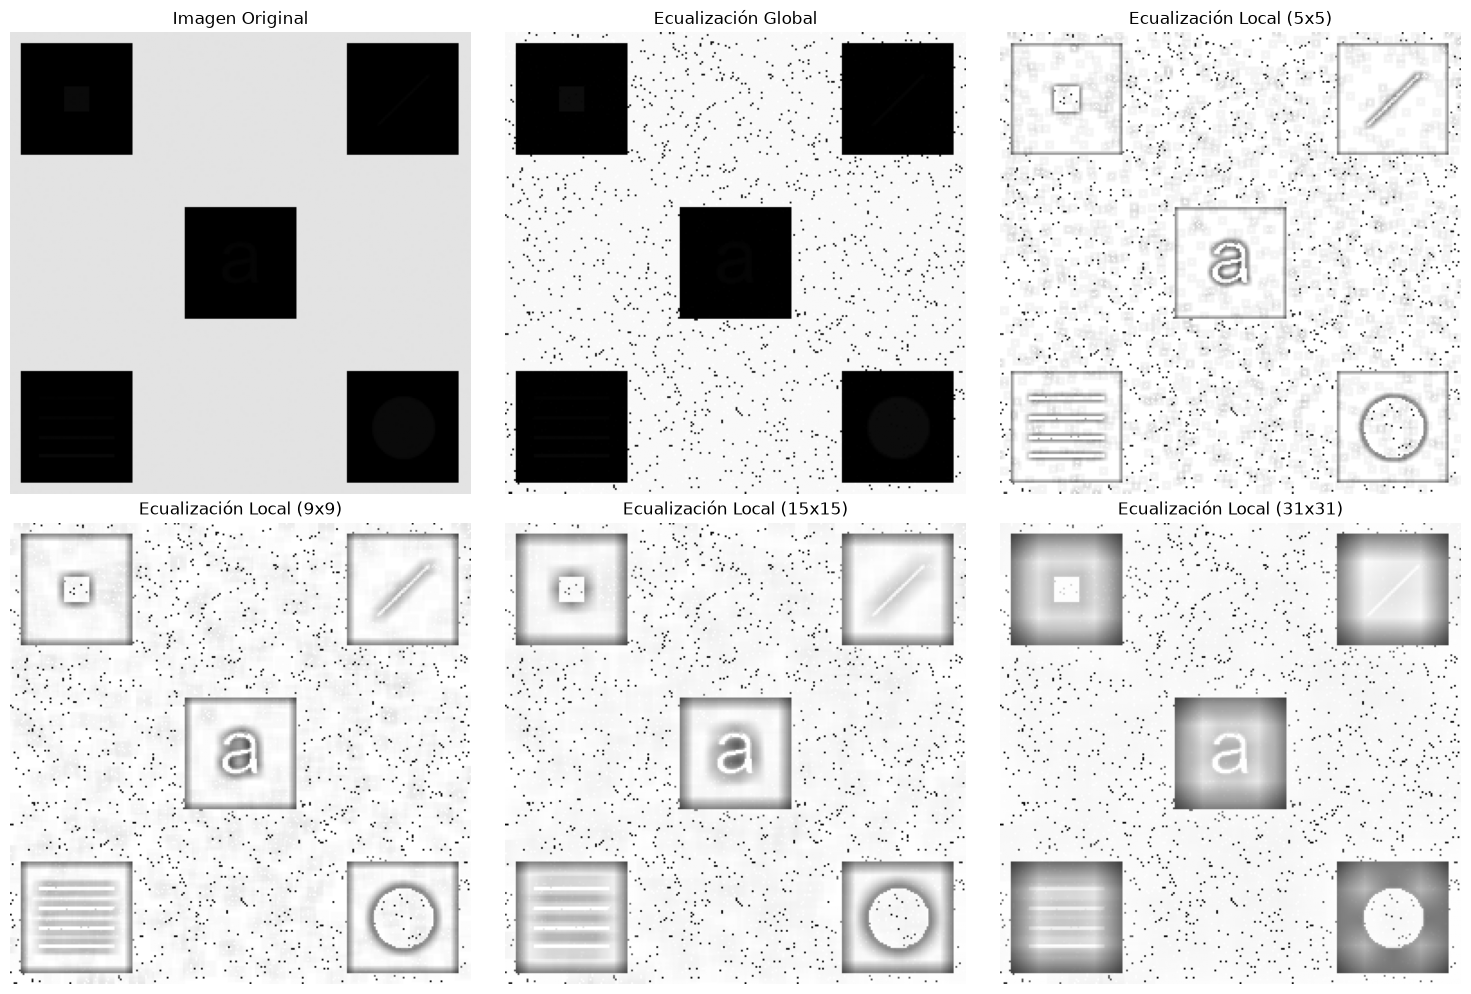

In [8]:
# ==========================================
# 2. Carga y procesamiento de la imagen
# ==========================================
ruta_imagen = '../images/raw/Imagen_con_detalles_escondidos.tif'
img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

# Ecualización global
img_global = cv2.equalizeHist(img)

# Ecualización local con diferentes tamaños de ventana
img_loc_5  = ecualizacion_local_histograma(img, (5, 5))
img_loc_9 = ecualizacion_local_histograma(img, (9, 9))
img_loc_15 = ecualizacion_local_histograma(img, (15, 15))
img_loc_31 = ecualizacion_local_histograma(img, (31, 31))

# ==========================================
# 3. Visualización y Comparación
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

axs[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title('Imagen Original')
axs[0, 0].axis('off')

axs[0, 1].imshow(img_global, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title('Ecualización Global')
axs[0, 1].axis('off')

axs[0, 2].imshow(img_loc_5, cmap='gray', vmin=0, vmax=255)
axs[0, 2].set_title('Ecualización Local (5x5)')
axs[0, 2].axis('off')

axs[1, 0].imshow(img_loc_9, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title('Ecualización Local (9x9)')
axs[1, 0].axis('off')

axs[1, 1].imshow(img_loc_15, cmap='gray', vmin=0, vmax=255)
axs[1, 1].set_title('Ecualización Local (15x15)')
axs[1, 1].axis('off')

axs[1, 2].imshow(img_loc_31, cmap='gray', vmin=0, vmax=255)
axs[1, 2].set_title('Ecualización Local (31x31)')
axs[1, 2].axis('off')

plt.tight_layout()

plt.savefig(
    '../images/output/problema_1.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()